In [1]:
import pandas as pd
from functools import lru_cache
import ast
import re

import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
import sys
sys.path.append("/Users/tahreemyasir/Documents/prelims/DT_hint-1")

from dt_code.GPT.csv_baseline_1 import convert_rule_to_short_name


neo4j+s://e6263dd9.databases.neo4j.io


# Loading data into separate df's 

In [2]:

df_1 = pd.read_csv('/Users/tahreemyasir/Documents/prelims/DT_hint-1/Data/csv/gpt/gpt_baseline_1.csv')
df_2 = pd.read_csv('/Users/tahreemyasir/Documents/prelims/DT_hint-1/Data/csv/gpt/gpt_baseline_2.csv')
df_3 = pd.read_csv('/Users/tahreemyasir/Documents/prelims/DT_hint-1/Data/csv/gpt/gpt_ours.csv')

# Convert df_1['id'] from string format like '[450]' to integer 450
# This ensures all DataFrames have the same dtype for the 'id' column
df_1['id'] = df_1['id'].astype(str).str.strip('[]').astype(int)

# df_1.isnull().sum()   
print("original number of rows baseline 1: ", len(df_1))
print("original number of rows baseline 2: ", len(df_2))
print("original number of rows baseline 3: ", len(df_3))

print("unique ids baseline 1: ", df_1['id'].nunique())
print("unique ids baseline 2: ", df_2['id'].nunique())
print("unique ids baseline 3: ", df_3['id'].nunique())

print("columns baseline 1: ", df_1.shape[1])
print("columns baseline 2: ", df_2.shape[1])
print("columns baseline 3: ", df_3.shape[1])

df = (
    df_1
    .merge(df_2, on="id", how="inner")
    .merge(df_3, on="id", how="inner")
)

print("columns merged: ", df.shape[1])
print("rows merged: ", df.shape[0])
print("unique ids merged: ", df['id'].nunique())
df.isnull().sum()


#apply convert_rule_to_short_name(rule_name) to student_rule, student_update_rule, judge_student_update_rule, ours_student_update_rule from gpt/csv_baseline_1.py
from dt_code.GPT.csv_baseline_1 import convert_rule_to_short_name
# remove space from KG_rule, student_rule, student_update_rule, judge_student_update_rule, ours_student_update_rule
df['KG_rule'] = df['KG_rule'].str.replace(' ', '')
df['student_rule'] = df['student_rule'].str.replace(' ', '')
df['student_update_rule'] = df['student_update_rule'].str.replace(' ', '')
df['judge_student_update_rule'] = df['judge_student_update_rule'].str.replace(' ', '')
df['ours_student_update_rule'] = df['ours_student_update_rule'].str.replace(' ', '')

for col in [
    'KG_rule',
    'student_rule', 
    'student_update_rule',
    'judge_student_update_rule',
    'ours_student_update_rule'
]:
    if col in df.columns:
        df[col] = df[col].astype(str).apply(convert_rule_to_short_name)



original number of rows baseline 1:  516
original number of rows baseline 2:  516
original number of rows baseline 3:  516
unique ids baseline 1:  516
unique ids baseline 2:  516
unique ids baseline 3:  516
columns baseline 1:  43
columns baseline 2:  12
columns baseline 3:  15
columns merged:  68
rows merged:  516
unique ids merged:  516


# preprocessing 

In [3]:
#Removing spaces from the columns
df['KG_step_new'] = df['KG_step'].str.replace(' ', '')
df['student_step_new'] = df['student_step'].str.replace(' ', '')
df['student_update_step_new'] = df['student_update_step'].str.replace(' ', '')
df['judge_student_update_step_new'] = df['judge_student_update_step'].str.replace(' ', '')
df['ours_student_update_step'] = df['ours_student_update_step'].str.replace(' ', '')
# remove '(' and ')' from the student_step and student_update_plan and KG_step
df['student_step_new'] = df['student_step'].str.replace('(', '').str.replace(')', '')
df['student_update_step_new'] = df['student_update_step'].str.replace('(', '').str.replace(')', '')
df['KG_step_new'] = df['KG_step'].str.replace('(', '').str.replace(')', '')
df['judge_student_update_step_new'] = df['judge_student_update_step'].str.replace('(', '').str.replace(')', '')
df['ours_student_update_step_new'] = df['ours_student_update_step'].str.replace('(', '').str.replace(')', '')



# count rows where student_distance == 0
print("number of rows where student_distance == 0: ", len(df_1[df_1['student_distance'] == 0]))
# show the rows where student_distance == 0
print(df[df['student_distance'] == 0][['conclusion', 'student_step', 'student_distance']])
# add 7 to the student_distance column
df['student_distance'] = df['student_distance'].fillna(0)
# replace 0 with 7 in the student_distance column
df['student_distance'] = df['student_distance'].replace(0, 7)
print(df[df['student_distance'] == 0][['conclusion', 'student_step', 'student_distance']])
# setting the student_depth to 3 if it is None
df['student_depth'] = df['student_depth'].fillna(3)
#if student_depth <0 set it to 3
df['student_depth'] = df['student_depth'].apply(lambda x: 3 if x < 0 else x)
print("student depth unique values: ", df['student_depth'].unique())
df['student_distance'] = df['student_distance'].apply(lambda x: 3 if x < 0 else x)
print("student distance unique values: ", df['student_distance'].unique())

#apply rule name preprocessing to student_rule, student_update_rule, judge_student_update_rule, ours_student_update_rule from gpt/csv_baseline_1.py
from dt_code.GPT.csv_baseline_1 import convert_rule_to_short_name

for col in [
    'KG_rule',
    'student_rule',
    'student_update_rule',
    'judge_student_update_rule',
    'ours_student_update_rule'
]:
    if col in df.columns:
        df[col] = df[col].astype(str).apply(convert_rule_to_short_name)

# Safe function to evaluate literal expressions - handles both strings and already-parsed lists
def safe_literal_eval(x):
    if isinstance(x, str):
        return ast.literal_eval(x)
    elif isinstance(x, (list, tuple)):
        return x
    else:
        return x

df['student_parent_complexities'] = df['student_parent_complexities'].apply(safe_literal_eval)

# Create known_expressions_length and parents_length columns for use in later cells
if 'known_expressions' in df.columns:
    df['known_expressions'] = df['known_expressions'].apply(safe_literal_eval)
    df['known_expressions_length'] = df['known_expressions'].apply(len)
if 'student_parent_statements' in df.columns:
    df['student_parent_statements'] = df['student_parent_statements'].apply(safe_literal_eval)
    df['parents_length'] = df['student_parent_statements'].apply(len)




number of rows where student_distance == 0:  4
    conclusion student_step  student_distance
118     (-B*H)          NaN                 0
119     (-B*H)          NaN                 0
192          Y          NaN                 0
363      (X+S)        (T>S)                 0
Empty DataFrame
Columns: [conclusion, student_step, student_distance]
Index: []
student depth unique values:  [3. 1. 4. 5. 2. 6. 7.]
student distance unique values:  [4 5 3 2 1 6 7]


# Optimal comparison 

In [4]:
#count the number of rows where student_step == KG_step
df['count_student'] = df.apply(lambda row: 1 if (row['student_step_new'] == row['KG_step_new']) & (row['student_rule'] == row['KG_rule']) else 0, axis=1)
print("================================================")
#optimal steps
print("Optimal number of steps: ", df['count_student'].sum())
pre_count = df['count_student'].sum()  # Count of optimal steps
pre = pre_count/df.shape[0]  # Proportion of optimal steps
print("Optimal number of steps: ", pre)
df_opt = df[df['count_student'] == 1].copy()
df_in = df[df['count_student'] == 0].copy()

# optimal step complexity
print("mean complexity of optimal steps: ", df_opt['student_complexity'].mean())
print("mean distance of optimal steps: ", df_opt['student_distance'].mean())
# optimal step already derived statements... 
# optimal step parents complexity 
# print("mean complexity of parent statements for optimal steps: ", 
#       df_opt['student_parent_complexities'].apply(lambda x: sum(x)/len(x) if len(x) > 0 else 10).mean())
# print("optimal steps mean derived statements: ", df_opt['known_expressions_length'].mean())
# print("optimal steps parents complexitys: ", df_opt['student_parent_complexities'].apply(lambda x: sum(x)/len(x) if len(x) > 0 else 10).mean())
# print("optimal steps mean parent statements: ", df_opt['parents_length'].mean())
print("================================================")
# find suboptimal steps
df_in['count_sub'] = df_in.apply(lambda row: 1 if str(row['student_step']) in str(row['filtered_derivation_keys']) else 0, axis=1)
print("suboptimal steps: ", df_in['count_sub'].sum())

# suboptimal steps with depth==1 and complexity details
df_sub_1 = df_in[df_in['count_sub'] == 1].copy()
print("suboptimal steps: ", (df_sub_1.shape[0]/df.shape[0]))
print("================================================")
# suboptimal steps with depth 1
# complexity details
print("suboptimal steps with depth 1: ", (df_sub_1['student_depth']==1).sum()/df.shape[0])
print("\n")
print("mean complexity of suboptimal steps at depth==1: ", df_sub_1[df_sub_1['student_depth']==1]['student_complexity'].mean())
print("actual complexity of suboptimal steps at depth==1: ", df_sub_1[df_sub_1['student_depth']==1]['KG_complexity'].mean())
print("complexity gap of suboptimal steps at depth==1: ", df_sub_1[df_sub_1['student_depth']==1]['student_complexity'].mean() - df_sub_1[df_sub_1['student_depth']==1]['KG_complexity'].mean())
print("\n")
# distance details
print("mean distance of suboptimal steps at depth==1: ", df_sub_1[df_sub_1['student_depth']==1]['student_distance'].mean())
print("actual distance of suboptimal steps at depth==1: ", df_sub_1[df_sub_1['student_depth']==1]['KG_distance'].mean())
print("distance gap of suboptimal steps at depth==1: ", df_sub_1[df_sub_1['student_depth']==1]['student_distance'].mean() - df_sub_1[df_sub_1['student_depth']==1]['KG_distance'].mean())
print("================================================")
print("suboptimal steps with depth > 1: ", (df_sub_1['student_depth']>1).sum()/df.shape[0])
print("\n")
print("mean complexity of suboptimal steps at depth>1: ", df_sub_1[df_sub_1['student_depth']>1]['student_complexity'].mean())
print("actual complexity of suboptimal steps at depth>1: ", df_sub_1[df_sub_1['student_depth']>1]['KG_complexity'].mean())
print("complexity gap of suboptimal steps at depth>1: ", df_sub_1[df_sub_1['student_depth']>1]['student_complexity'].mean() - df_sub_1[df_sub_1['student_depth']>1]['KG_complexity'].mean())
print("\n")
print("mean depth of suboptimal steps at depth>1: ", df_sub_1[df_sub_1['student_depth']>1]['student_depth'].mean())
print("actual depth of suboptimal steps at depth>1: ", df_sub_1[df_sub_1['student_depth']>1]['KG_depth'].mean())
print("depth gap of suboptimal steps at depth>1: ", df_sub_1[df_sub_1['student_depth']>1]['student_depth'].mean() - df_sub_1[df_sub_1['student_depth']>1]['KG_depth'].mean())
print("\n")
print("mean distance of suboptimal steps at depth>1: ", df_sub_1[df_sub_1['student_depth']>1]['student_distance'].mean())
print("actual distance of suboptimal steps at depth>1: ", df_sub_1[df_sub_1['student_depth']>1]['KG_distance'].mean())
print("distance gap of suboptimal steps at depth>1: ", df_sub_1[df_sub_1['student_depth']>1]['student_distance'].mean() - df_sub_1[df_sub_1['student_depth']>1]['KG_distance'].mean())
print("================================================")
print("incorrect steps: ", (df_in['count_sub']==0).sum()/df.shape[0])
print("\n")
print("mean complexity of incorrect steps: ", df_in[df_in['count_sub']==0]['student_complexity'].mean())
print("actual complexity of incorrect steps: ", df_in[df_in['count_sub']==0]['KG_complexity'].mean())
print("complexity gap of incorrect steps: ", df_in[df_in['count_sub']==0]['student_complexity'].mean() - df_in[df_in['count_sub']==0]['KG_complexity'].mean())
print("\n")
print("mean depth of incorrect steps: ", df_in[df_in['count_sub']==0]['student_depth'].mean())
print("actual depth of incorrect steps: ", df_in[df_in['count_sub']==0]['KG_depth'].mean())
print("depth gap of incorrect steps: ", df_in[df_in['count_sub']==0]['student_depth'].mean() - df_in[df_in['count_sub']==0]['KG_depth'].mean())
print("\n")
print("mean distance of incorrect steps: ", df_in[df_in['count_sub']==0]['student_distance'].mean())
print("actual distance of incorrect steps: ", df_in[df_in['count_sub']==0]['KG_distance'].mean())
print("distance gap of incorrect steps: ", df_in[df_in['count_sub']==0]['student_distance'].mean() - df_in[df_in['count_sub']==0]['KG_distance'].mean())

print("================================================")

df_in['count_teacher'] = df_in.apply(lambda row: 1 if (row['student_update_step_new'] == row['KG_step_new']) & (row['student_update_rule'] == row['KG_rule']) else 0, axis=1)
teacher_correct = df_in['count_teacher'].sum()
print("teacher correct: ", teacher_correct)
post_teacher = (teacher_correct+pre_count)/df.shape[0]
print("post teacher feedback: ", post_teacher)

df_in['count_judge'] = df_in.apply(lambda row: 1 if (row['judge_student_update_step_new'] == row['KG_step_new']) & (row['judge_student_update_rule'] == row['KG_rule']) else 0, axis=1)
judge_correct = df_in['count_judge'].sum()
post_judge = (judge_correct+pre_count)/df.shape[0]
print("judge correct: ", judge_correct)
print("post judge feedback: ", post_judge)

df_in['count_ours'] = df_in.apply(lambda row: 1 if (row['ours_student_update_step_new'] == row['KG_step_new']) & (row['ours_student_update_rule'] == row['KG_rule']) else 0, axis=1)
ours_correct = df_in['count_ours'].sum()
post_ours = (ours_correct+pre_count)/df.shape[0]
print("ours correct: ", ours_correct)
print("post our feedback: ", post_ours)


print("================================================")
ecr_teacher = (teacher_correct)/(df.shape[0]-pre_count)
ecr_judge = (judge_correct)/(df.shape[0]-pre_count)
ecr_ours = (ours_correct)/(df.shape[0]-pre_count)

print("ecr_teacher: ", ecr_teacher)
print("ecr_judge: ", ecr_judge)
print("ecr_ours: ", ecr_ours)


Optimal number of steps:  110
Optimal number of steps:  0.2131782945736434
mean complexity of optimal steps:  1.8818181818181818
mean distance of optimal steps:  2.6545454545454548
suboptimal steps:  333
suboptimal steps:  0.6453488372093024
suboptimal steps with depth 1:  0.1511627906976744


mean complexity of suboptimal steps at depth==1:  1.8717948717948718
actual complexity of suboptimal steps at depth==1:  3.5256410256410255
complexity gap of suboptimal steps at depth==1:  -1.6538461538461537


mean distance of suboptimal steps at depth==1:  2.923076923076923
actual distance of suboptimal steps at depth==1:  2.769230769230769
distance gap of suboptimal steps at depth==1:  0.15384615384615374
suboptimal steps with depth > 1:  0.4941860465116279


mean complexity of suboptimal steps at depth>1:  1.7098039215686274
actual complexity of suboptimal steps at depth>1:  3.1294117647058823
complexity gap of suboptimal steps at depth>1:  -1.419607843137255


mean depth of suboptimal steps 

# PNIR 

In [157]:

# Count positive and negative instruction
P = (df_in["count_teacher"] == 1).sum()
N = (df_in["count_teacher"] == 0).sum()

# PNIR
pnir = N / P if P > 0 else float("inf")
print(f"P = {P}, N = {N}, Judge PNIR = {pnir:.3f}")


# Count positive and negative instruction
P = (df_in["count_judge"] == 1).sum()
N = (df_in["count_judge"] == 0).sum()

# PNIR
pnir = N / P if P > 0 else float("inf")
print(f"P = {P}, N = {N}, Judge PNIR = {pnir:.3f}")


# Count positive and negative instruction
P = (df_in["count_ours"] == 1).sum()
N = (df_in["count_ours"] == 0).sum()

# PNIR
pnir = N / P if P > 0 else float("inf")
print(f"P = {P}, N = {N}, Judge PNIR = {pnir:.3f}")


P = 111, N = 295, Judge PNIR = 2.658
P = 206, N = 200, Judge PNIR = 0.971
P = 279, N = 127, Judge PNIR = 0.455


# Teacher rule accuracy 

In [158]:
import pandas as pd

# Binary correctness
df["teacher_rule_correct"] = (df["teacher_rule"] == df["KG_rule"]).astype(int)

# Total teacher rule accuracy
total_teacher_rule_accuracy = df["teacher_rule_correct"].mean()

print(f"Total Teacher Rule Accuracy: {total_teacher_rule_accuracy:.3f}")


# Binary correctness per instance
df["teacher_rule_correct"] = (df["teacher_rule"] == df["KG_rule"]).astype(int)

# Accuracy per gold rule
teacher_rule_accuracy = (
    df.groupby("KG_rule")
      .agg(
          total_instances=("teacher_rule_correct", "count"),
          correct_predictions=("teacher_rule_correct", "sum"),
          accuracy=("teacher_rule_correct", "mean")
      )
      .reset_index()
      .sort_values("total_instances", ascending=False)
)

print(teacher_rule_accuracy)
teacher_rule_confusion = (
    df.groupby(["KG_rule", "teacher_rule"])
      .agg(
          count=("teacher_rule", "size"),
          correct=("teacher_rule_correct", "sum")
      )
      .reset_index()
      .sort_values(["KG_rule", "count"], ascending=[True, False])
)

# print(teacher_rule_confusion)


Total Teacher Rule Accuracy: 0.583
   KG_rule  total_instances  correct_predictions  accuracy
14    Simp               90                   79  0.877778
0      Add               61                   50  0.819672
12      MP               61                   43  0.704918
6       DS               53                   23  0.433962
13      MT               40                   20  0.500000
11    Impl               38                   18  0.473684
2       CP               36                   11  0.305556
5       DN               31                   15  0.483871
1       CD               27                    2  0.074074
7      DeM               21                   10  0.476190
10      HS               21                   10  0.476190
4     Conj               14                   13  0.928571
3      Com               12                    5  0.416667
9    Equiv                7                    0  0.000000
8     Dist                2                    2  1.000000
15     nan           

# Student Rule Accuracy 

In [159]:
# Initial correctness
df["init_correct"] = (df["student_rule"] == df["KG_rule"]).astype(int)

# Correction indicators (only meaningful if init_correct == 0)
df["tutor_corrected"] = (
    (df["init_correct"] == 0) &
    (df["student_update_rule"] == df["KG_rule"])
).astype(int)

df["teacher_corrected"] = (
    (df["init_correct"] == 0) &
    (df["judge_student_update_rule"] == df["KG_rule"])
).astype(int)

df["judge_corrected"] = (
    (df["init_correct"] == 0) &
    (df["ours_student_update_rule"] == df["KG_rule"])
).astype(int)

rule_correction = (
    df[df["init_correct"] == 0]  # only initially wrong
    .groupby("KG_rule")
    .agg(
        total_errors=("KG_rule", "count"),
        tutor_fixed=("tutor_corrected", "sum"),
        teacher_fixed=("teacher_corrected", "sum"),
        judge_fixed=("judge_corrected", "sum"),
    )
)

# Convert to rates
rule_correction["tutor_rate"] = rule_correction["tutor_fixed"] / rule_correction["total_errors"]
rule_correction["teacher_rate"] = rule_correction["teacher_fixed"] / rule_correction["total_errors"]
rule_correction["judge_rate"] = rule_correction["judge_fixed"] / rule_correction["total_errors"]

rule_correction = rule_correction.sort_values("total_errors", ascending=False)
print(rule_correction)

resistant_rules = rule_correction[
    rule_correction["judge_rate"] < 0.25
].sort_values("judge_rate")

print(resistant_rules)

persistent_confusion = (
    df[(df["init_correct"] == 0) &
       (df["ours_student_update_rule"] != df["KG_rule"])]
    .groupby(["KG_rule", "ours_student_update_rule"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
print(persistent_confusion)

         total_errors  tutor_fixed  teacher_fixed  judge_fixed  tutor_rate  \
KG_rule                                                                      
Simp               69           46             53           63    0.666667   
Add                43           23             32           40    0.534884   
DS                 36           16             32           31    0.444444   
Impl               33            6             15           23    0.181818   
CP                 29            0             15           18    0.000000   
MP                 28           14             25           25    0.500000   
CD                 26            8             16           22    0.307692   
DN                 25            6             16           21    0.240000   
MT                 25            6             17           22    0.240000   
HS                 14            7              9           14    0.500000   
DeM                13            5              9           10  

# Feedback hurts or improve 

In [5]:
# rows where count_student == 0 and count_ours == 0
df_degrading = df_in[(df_in['count_student'] == 0) & (df_in['count_teacher'] == 1) ]

print('imrpoved steps teacher: ', df_degrading.shape[0])
print('steps complexity: ', df_degrading['KG_complexity'].mean())
# in count number of rows in df_degrading, rows where teacher_rule == KG_rule
print('teacher rule == KG_rule: ',df_degrading[df_degrading['teacher_rule'] == df_degrading['KG_rule']].shape[0])
print('student step new == KG_step new: ',df_degrading[df_degrading['student_step_new'] == df_degrading['KG_step_new']].shape[0])
print('student rule == KG_rule: ',df_degrading[df_degrading['student_rule'] == df_degrading['KG_rule']].shape[0])
print('student rule == teacher rule and != KG_rule: ',df_degrading[(df_degrading['student_rule'] == df_degrading['teacher_rule']) & (df_degrading['teacher_rule'] != df_degrading['KG_rule'])].shape[0])
print('student step or rule == KG_step or rule: ',df_degrading[(df_degrading['student_step_new'] == df_degrading['KG_step_new']) | (df_degrading['student_rule'] == df_degrading['KG_rule'])].shape[0])
print('--------------------------------')
df_degrading = df_in[(df_in['count_student'] == 0) & (df_in['count_judge'] == 1) ]
print('teacher improved steps: ', df_degrading.shape[0])
print('steps complexity: ', df_degrading['KG_complexity'].mean())
print('student step or rule == KG_step or rule: ',df_degrading[(df_degrading['student_step_new'] == df_degrading['KG_step_new']) | (df_degrading['student_rule'] == df_degrading['KG_rule'])].shape[0])
print('teacher_rule == kg_rule: ', df_degrading[df_degrading['teacher_rule'] == df_degrading['KG_rule']].shape[0])
print('student rule == teacher rule and != KG_rule: ',df_degrading[(df_degrading['student_rule'] == df_degrading['teacher_rule']) & (df_degrading['teacher_rule'] != df_degrading['KG_rule'])].shape[0])
print('--------------------------------')
df_degrading = df_in[(df_in['count_student'] == 0) & (df_in['count_ours'] == 1) ]
print('ours improved steps: ', df_degrading.shape[0])
print('steps complexity: ', df_degrading['KG_complexity'].mean())
print('student step or rule == KG_step or rule: ',df_degrading[(df_degrading['student_step_new'] == df_degrading['KG_step_new']) | (df_degrading['student_rule'] == df_degrading['KG_rule'])].shape[0])
print('teacher rule == KG_rule: ',df_degrading[df_degrading['teacher_rule'] == df_degrading['KG_rule']].shape[0])
print('student rule == teacher rule and != KG_rule: ',df_degrading[(df_degrading['student_rule'] == df_degrading['teacher_rule']) & (df_degrading['teacher_rule'] != df_degrading['KG_rule'])].shape[0])
print('--------------------------------')
df_degrading = df_in[(df_in['count_student'] == 0) &  (df_in['count_teacher'] == 0) & (df_in['count_ours'] == 1) ]
print('teacher degrade, ours improved steps: ', df_degrading.shape[0])
print('steps complexity: ', df_degrading['KG_complexity'].mean())
print('student step or rule == KG_step or rule: ',df_degrading[(df_degrading['student_step_new'] == df_degrading['KG_step_new']) | (df_degrading['student_rule'] == df_degrading['KG_rule'])].shape[0])
print('teacher rule == KG_rule: ',df_degrading[df_degrading['teacher_rule'] == df_degrading['KG_rule']].shape[0])
print('student rule == teacher rule and != KG_rule: ',df_degrading[(df_degrading['student_rule'] == df_degrading['teacher_rule']) & (df_degrading['teacher_rule'] != df_degrading['KG_rule'])].shape[0])
print('--------------------------------')
df_degrading = df_in[(df_in['count_student'] == 0) &  (df_in['count_judge'] == 0) & (df_in['count_ours'] == 1) ]
print('judge degrade, ours improved steps: ', df_degrading.shape[0])
print('steps complexity: ', df_degrading['KG_complexity'].mean())
print('student step or rule == KG_step or rule: ',df_degrading[(df_degrading['student_step_new'] == df_degrading['KG_step_new']) | (df_degrading['student_rule'] == df_degrading['KG_rule'])].shape[0])
print('teacher rule == KG_rule: ',df_degrading[df_degrading['teacher_rule'] == df_degrading['KG_rule']].shape[0])
print('student rule == teacher rule and != KG_rule: ',df_degrading[(df_degrading['student_rule'] == df_degrading['teacher_rule']) & (df_degrading['teacher_rule'] != df_degrading['KG_rule'])].shape[0])
print('--------------------------------')
df_degrading = df_in[(df_in['count_student'] == 0) &  (df_in['count_teacher'] == 1) & (df_in['count_ours'] == 1) ]
print('teacher improved, ours improved steps: ', df_degrading.shape[0])
print('steps complexity: ', df_degrading['KG_complexity'].mean())
print('student step or rule == KG_step or rule: ',df_degrading[(df_degrading['student_step_new'] == df_degrading['KG_step_new']) | (df_degrading['student_rule'] == df_degrading['KG_rule'])].shape[0])
print('teacher rule == KG_rule: ',df_degrading[df_degrading['teacher_rule'] == df_degrading['KG_rule']].shape[0])
print('student rule == teacher rule and != KG_rule: ',df_degrading[(df_degrading['student_rule'] == df_degrading['teacher_rule']) & (df_degrading['teacher_rule'] != df_degrading['KG_rule'])].shape[0])


imrpoved steps teacher:  111
steps complexity:  1.864864864864865
teacher rule == KG_rule:  94
student step new == KG_step new:  0
student rule == KG_rule:  10
student rule == teacher rule and != KG_rule:  2
student step or rule == KG_step or rule:  10
--------------------------------
teacher improved steps:  206
steps complexity:  2.2184466019417477
student step or rule == KG_step or rule:  38
teacher_rule == kg_rule:  117
student rule == teacher rule and != KG_rule:  35
--------------------------------
ours improved steps:  279
steps complexity:  2.7096774193548385
student step or rule == KG_step or rule:  42
teacher rule == KG_rule:  143
student rule == teacher rule and != KG_rule:  52
--------------------------------
teacher degrade, ours improved steps:  174
steps complexity:  3.206896551724138
student step or rule == KG_step or rule:  32
teacher rule == KG_rule:  54
student rule == teacher rule and != KG_rule:  50
--------------------------------
judge degrade, ours improved step

In [161]:
# rows where count_student == 0 and count_ours == 0
df_degrading = df_in[(df_in['count_student'] == 0) & (df_in['count_teacher'] == 0) ]

print('degraded steps teacher: ', df_degrading.shape[0])
print('steps complexity: ', df_degrading['KG_complexity'].mean())
# in count number of rows in df_degrading, rows where teacher_rule == KG_rule
print('teacher rule == KG_rule: ',df_degrading[df_degrading['teacher_rule'] == df_degrading['KG_rule']].shape[0])
print('student step new == KG_step new: ',df_degrading[df_degrading['student_step_new'] == df_degrading['KG_step_new']].shape[0])
print('student rule == KG_rule: ',df_degrading[df_degrading['student_rule'] == df_degrading['KG_rule']].shape[0])
print('student rule == teacher rule and != KG_rule: ',df_degrading[(df_degrading['student_rule'] == df_degrading['teacher_rule']) & (df_degrading['teacher_rule'] != df_degrading['KG_rule'])].shape[0])
print('student step or rule == KG_step or rule: ',df_degrading[(df_degrading['student_step_new'] == df_degrading['KG_step_new']) | (df_degrading['student_rule'] == df_degrading['KG_rule'])].shape[0])
print('--------------------------------')
df_degrading = df_in[(df_in['count_student'] == 0) & (df_in['count_judge'] == 0) ]
print('judge degraded steps: ', df_degrading.shape[0])
print('steps complexity: ', df_degrading['KG_complexity'].mean())
print('student step or rule == KG_step or rule: ',df_degrading[(df_degrading['student_step_new'] == df_degrading['KG_step_new']) | (df_degrading['student_rule'] == df_degrading['KG_rule'])].shape[0])
print('teacher_rule == kg_rule: ', df_degrading[df_degrading['teacher_rule'] == df_degrading['KG_rule']].shape[0])
print('student rule == teacher rule and != KG_rule: ',df_degrading[(df_degrading['student_rule'] == df_degrading['teacher_rule']) & (df_degrading['teacher_rule'] != df_degrading['KG_rule'])].shape[0])
print('--------------------------------')
df_degrading = df_in[(df_in['count_student'] == 0) & (df_in['count_ours'] == 0) ]
print('ours degraded steps: ', df_degrading.shape[0])
print('steps complexity: ', df_degrading['KG_complexity'].mean())
print('student step or rule == KG_step or rule: ',df_degrading[(df_degrading['student_step_new'] == df_degrading['KG_step_new']) | (df_degrading['student_rule'] == df_degrading['KG_rule'])].shape[0])
print('teacher rule == KG_rule: ',df_degrading[df_degrading['teacher_rule'] == df_degrading['KG_rule']].shape[0])
print('student rule == teacher rule and != KG_rule: ',df_degrading[(df_degrading['student_rule'] == df_degrading['teacher_rule']) & (df_degrading['teacher_rule'] != df_degrading['KG_rule'])].shape[0])
print('--------------------------------')
df_degrading = df_in[(df_in['count_student'] == 0) &  (df_in['count_teacher'] == 0) & (df_in['count_ours'] == 0) ]
print('teacher degrade, ours degraded steps: ', df_degrading.shape[0])
print('steps complexity: ', df_degrading['KG_complexity'].mean())
print('student step or rule == KG_step or rule: ',df_degrading[(df_degrading['student_step_new'] == df_degrading['KG_step_new']) | (df_degrading['student_rule'] == df_degrading['KG_rule'])].shape[0])
print('teacher rule == KG_rule: ',df_degrading[df_degrading['teacher_rule'] == df_degrading['KG_rule']].shape[0])
print('student rule == teacher rule and != KG_rule: ',df_degrading[(df_degrading['student_rule'] == df_degrading['teacher_rule']) & (df_degrading['teacher_rule'] != df_degrading['KG_rule'])].shape[0])


degraded steps teacher:  295
steps complexity:  3.9728813559322034
teacher rule == KG_rule:  98
student step new == KG_step new:  16
student rule == KG_rule:  31
student rule == teacher rule and != KG_rule:  62
student step or rule == KG_step or rule:  47
--------------------------------
judge degraded steps:  200
steps complexity:  4.61
student step or rule == KG_step or rule:  19
teacher_rule == kg_rule:  75
student rule == teacher rule and != KG_rule:  29
--------------------------------
ours degraded steps:  127
steps complexity:  4.905511811023622
student step or rule == KG_step or rule:  15
teacher rule == KG_rule:  49
student rule == teacher rule and != KG_rule:  12
--------------------------------
teacher degrade, ours degraded steps:  121
steps complexity:  5.074380165289257
student step or rule == KG_step or rule:  15
teacher rule == KG_rule:  44
student rule == teacher rule and != KG_rule:  12


In [162]:
# df_in[(df_in['count_student'] == 0) & (df_in['count_teacher'] == 0)][['KG_step_new', 'KG_rule', 'student_step_new', 'student_rule', 'teacher_rule', 'student_update_step_new', 'student_update_rule']]

#judge degrading steps and feedback
# df_in[(df_in['count_student'] == 0) & (df_in['count_teacher'] == 0) & (df_in['count_judge'] == 1) & (df_in['count_ours'] == 1)][['KG_step_new', 'KG_rule', 'student_step_new', 'student_rule','student_update_step_new', 'student_update_rule','judge_student_update_step_new', 'judge_student_update_rule', 'ours_student_update_step_new', 'ours_student_update_rule','count_sub','judge_feedback', 'teacher_feedback','final_feedback_ours']]


# Responses for evaluations 

In [ ]:
df_in.loc[
    (df_in["count_student"] == 0) &
    (df_in["count_teacher"] == 0) &
    (df_in["count_judge"] == 0) &
    (df_in["count_ours"] == 1),
    [
        "givens", "intermediate_expressions", "conclusion", "KG_step",
        "KG_plan", 'student_step_new', 'count_sub','next_step_correctness_x', 'next_step_correctness_y', 'next_step_correctness_ours',"student_reasoning", "student_candidates",
       "teacher_feedback", 'judge_feedback', "final_feedback_ours"
    ]
]
# .head(50).to_clipboard(index=False)


,givens,intermediate_expressions,conclusion,KG_step,KG_plan,student_step_new,next_step_correctness_x,next_step_correctness_y,next_step_correctness_ours,student_reasoning,student_candidates,teacher_feedback,judge_feedback,final_feedback_ours
4,"['(J>H)', '(-W>(-H*-F))', 'J']","['H', '(H+F)', '(W+(-H*-F))']",W,(W+-(H+F)),Derive (W+-(H+F)) from (W+(-H*-F)) using the DeMorgan's Law rule.,W,Incorrect,Incorrect,Incorrect,"W is optimal because we already have (W+(-H*-F)), so if we can show -(-H*-F), then by Disjunctive Syllogism (DS), we can directly derive W, which is the conclusion. The other candidates either require more steps or do not directly use the available disjunction.","['(-H*-F) - (If we can get -W, then from (-W>(-H*-F)) and MP, we get (-H*-F))', 'W - (From (W+(-H*-F)) and -(-H*-F), use DS to get W)', ""-(-H*-F) - (If we can show -(H+F), then by De Morgan's, we get -H*-F, and then its negation)""]","Great job identifying the importance of the disjunction (W+(-H*-F)). Before you can apply DS, what must you establish about the other disjunct? Look at your candidates—can you derive something that helps you get the needed negation first?","You are on the right track by focusing on the disjunction (W+(-H*-F)), but before applying DS, consider how to relate (-H*-F) to a form that connects with your other available statements. What logical rule could help you rewrite (W+(-H*-F)) to make further progress toward W?","You're on the right track by focusing on the disjunction, but before you can use DS, you need to ensure the disjunction is in the right form. Can you think of a way to rewrite (W+(-H*-F)) so that it matches the negation you want to use? What logical law might help you here?"
5,"['(J>H)', '(-W>(-H*-F))', 'J']","['H', '(W+(-H*-F))']",W,((W+-H)*(W+-F)),Derive ((W+-H)*(W+-F)) from (W+(-H*-F)) using the Distributive rule.,W,Incorrect,Incorrect,Incorrect,"The first candidate, W by Disjunctive Syllogism on (W+(-H*-F)) and H, is optimal because we already have H and (W+(-H*-F)), and DS allows us to directly infer W, which is exactly the conclusion. The other candidates either do not directly yield W or require additional steps.","['W - (W+(-H*-F)), H; DS - Disjunctive Syllogism on (W+(-H*-F)) and H', '-H - H; DN - Double Negation on H', '(-H*-F) - (W+(-H*-F)), -W; DS - Disjunctive Syllogism on (W+(-H*-F)) and -W']","Great job identifying that (W+(-H*-F)) and H are important, but consider whether these statements actually allow you to apply DS. Is there a way to rewrite (W+(-H*-F)) to make its structure more useful for further inference? Which candidate might help you break down the disjunction more effectively?","Great job identifying that (W+(-H*-F)) and H are important! However, think about how you might break down (W+(-H*-F)) further using logical equivalences before applying DS. What rule could help you rewrite this expression to make the disjunctions clearer?","You correctly identified the relevant statements, but DS can't be applied here because you need the negation of one disjunct, not just H. How could you rewrite (W+(-H*-F)) to separate its components and make it more suitable for inference? What logical rule might help you break down the conjunction inside the disjunction?"
10,"['(J>H)', '(-W>(-H*-F))', 'J']","['H', '(H+F)', '(--H+F)', '(--H+--F)', '-(-H*-F)', '(--W+(-H*-F))']",W,--W,Derive --W from (-W>(-H*-F)) and -(-H*-F) using the Modus Tollens rule.,-H*-F,Incorrect,Incorrect,Incorrect,"(-H*-F) is optimal because it matches the consequent of the second given, and if we have (-H*-F), then by Modus Tollens on the contrapositive of the second given, we can derive W. The other candidates either do not directly help or are not immediately derivable.","['(-H*-F) - [If we can get this, we can use the contrapositive of the second given to get W]', '--W - [Double Negation on W, but we need W itself]', ""(-W>-H) - [Contraposition of the second given, but doesn't directly yield W]""]","You correctly identified the impor

# LLM assessment of steps 

In [ ]:
# optimal steps assessment
print("next_step_correctness_x:")
print(df_opt[df_opt['count_student'] == 1][['next_step_correctness_x']].value_counts())
print("\nnext_step_correctness_y:")
print(df_opt[df_opt['count_student'] == 1][['next_step_correctness_y']].value_counts())
print("\nnext_step_correctness_ours:")
print(df_opt[df_opt['count_student'] == 1][['next_step_correctness_ours']].value_counts())


# Value counts for next_step_correctness columns where count_student == 1
# Filter rows where count_student == 1
df_student_correct = df_opt[df_opt['count_student'] == 1]

# Print total number of rows where count_student == 1
print(f"Total number of rows where count_student == 1: {len(df_student_correct)}")
 

# suboptimal steps assessment
print("next_step_correctness_x:")
print(df_in[df_in['count_sub'] == 1][['next_step_correctness_x']].value_counts())
print("\nnext_step_correctness_y:")
print(df_in[df_in['count_sub'] == 1][['next_step_correctness_y']].value_counts())
print("\nnext_step_correctness_ours:")
print(df_in[df_in['count_sub'] == 1][['next_step_correctness_ours']].value_counts())


# Value counts for next_step_correctness columns where count_student == 1
# Filter rows where count_student == 1
df_student_suboptimal = df_in[df_in['count_sub'] == 1]

# Print total number of rows where count_student == 1
print(f"Total number of rows where count_sub == 1: {len(df_student_suboptimal)}")
 

next_step_correctness_x:
next_step_correctness_x
Correct                    109
Suboptimal                   1
Name: count, dtype: int64

next_step_correctness_y:
next_step_correctness_y
Correct                    106
Suboptimal                   3
Incorrect                    1
Name: count, dtype: int64

next_step_correctness_ours:
next_step_correctness_ours
Correct                       108
Suboptimal                      2
Name: count, dtype: int64
Total number of rows where count_student == 1: 110
next_step_correctness_x:
next_step_correctness_x
Incorrect                  159
Suboptimal                 135
Correct                     39
Name: count, dtype: int64

next_step_correctness_y:
next_step_correctness_y
Incorrect                  182
Suboptimal                 140
Correct                     11
Name: count, dtype: int64

next_step_correctness_ours:
next_step_correctness_ours
Incorrect                     200
Suboptimal                    130
Correct                         

# Regression preprocessing

In [165]:
# student_df
df_student = df[['id','KG_step_new' ,'KG_rule', 'KG_complexity', 'KG_distance', 'student_step_new', 'student_rule']].copy()
df_student['correct'] = df_student.apply(lambda row: 1 if (row['student_rule'] == row['KG_rule']) and (row['student_step_new'] == row['KG_step_new']) else 0, axis=1)
# add a column to df_student called 'model' which contains the "GPT-4.1"
df_student['model'] = "GPT-4.1"
# add a column to df_student called 'pipeline' which contains the "student only"
df_student['pipeline'] = "student only"
df_student.head()
# drop the KG_step, KG_rule, student_step, student_rule columns
df_student = df_student.drop(columns=['KG_step_new', 'KG_rule', 'student_step_new', 'student_rule'])

# pipeline 2 student-teacher
df_teacher = df[['id','KG_step' ,'KG_rule', 'KG_complexity', 'KG_distance', 'student_update_step', 'student_update_rule']].copy()
df_teacher['correct'] = df_teacher.apply(lambda row: 1 if (row['student_update_rule'] == row['KG_rule']) and (row['student_update_step'] == row['KG_step']) else 0, axis=1)
# add a column to df_student called 'model' which contains the "GPT-4.1"
df_teacher['model'] = "GPT-4.1"
# add a column to df_student called 'pipeline' which contains the "student only"
df_teacher['pipeline'] = "student-teacher"
df_teacher.head()
# drop the KG_step, KG_rule, student_step, student_rule columns
df_teacher = df_teacher.drop(columns=['KG_step', 'KG_rule', 'student_update_step', 'student_update_rule'])
df_teacher.head()


# pipeline 3 student-judge
df_judge = df[['id','KG_step' ,'KG_rule', 'KG_complexity', 'KG_distance', 'judge_student_update_step', 'judge_student_update_rule']].copy()
df_judge['correct'] = df_judge.apply(lambda row: 1 if (row['judge_student_update_rule'] == row['KG_rule']) and (row['judge_student_update_step'] == row['KG_step']) else 0, axis=1)
# add a column to df_student called 'model' which contains the "GPT-4.1"
df_judge['model'] = "GPT-4.1"
# add a column to df_student called 'pipeline' which contains the "student only"
df_judge['pipeline'] = "student-judge"
df_judge.head()
# drop the KG_step, KG_rule, student_step, student_rule columns
df_judge = df_judge.drop(columns=['KG_step', 'KG_rule', 'judge_student_update_step', 'judge_student_update_rule'])
df_judge.head()


# pipeline 4 student-teacher-judge
df_teacher_judge = df[['id','KG_step' ,'KG_rule', 'KG_complexity', 'KG_distance', 'ours_student_update_step', 'ours_student_update_rule']].copy()
df_teacher_judge['correct'] = df_teacher_judge.apply(lambda row: 1 if (row['ours_student_update_rule'] == row['KG_rule']) and (row['ours_student_update_step'] == row['KG_step']) else 0, axis=1)
# add a column to df_student called 'model' which contains the "GPT-4.1"
df_teacher_judge['model'] = "GPT-4.1"
# add a column to df_student called 'pipeline' which contains the "student only"
df_teacher_judge['pipeline'] = "student-teacher-judge"
df_teacher_judge.head()
# drop the KG_step, KG_rule, student_step, student_rule columns
df_teacher_judge = df_teacher_judge.drop(columns=['KG_step', 'KG_rule', 'ours_student_update_step', 'ours_student_update_rule'])
df_teacher_judge.head()


#vertical concat all dataframes
df_all = pd.concat([df_student, df_teacher, df_judge, df_teacher_judge])
print(df_all.shape)
df_all.head()




(2064, 6)


,id,KG_complexity,KG_distance,correct,model,pipeline
0,450,7,3,0,GPT-4.1,student only
1,451,2,4,0,GPT-4.1,student only
2,452,0,5,1,GPT-4.1,student only
3,453,7,3,0,GPT-4.1,student only
4,454,6,4,0,GPT-4.1,student only


In [166]:
df_all['pipeline'].unique()

array(['student only', 'student-teacher', 'student-judge',
       'student-teacher-judge'], dtype=object)

In [167]:
import statsmodels.formula.api as smf

# Ensure categorical variables are treated properly
df_all['pipeline'] = df_all['pipeline'].astype('category')
df_all['model'] = df_all['model'].astype('category')

# Logistic regression
model = smf.logit(
    formula="""
        correct ~ pipeline 
        + KG_complexity 
        + KG_distance
        + pipeline * KG_complexity
        + pipeline * KG_distance

    """,
    data=df_all
).fit()

print(model.summary())


Optimization terminated successfully.
         Current function value: 0.549311
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                correct   No. Observations:                 2064
Model:                          Logit   Df Residuals:                     2052
Method:                           MLE   Df Model:                           11
Date:                Mon, 12 Jan 2026   Pseudo R-squ.:                  0.1255
Time:                        15:51:07   Log-Likelihood:                -1133.8
converged:                       True   LL-Null:                       -1296.5
Covariance Type:            nonrobust   LLR p-value:                 3.770e-63
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
Intercept                         

In [168]:
import numpy as np

# Add OR column
results_df = pd.DataFrame({
    'Predictor': model.params.index,
    'β': model.params.values,
    'SE': model.bse.values,
    'OR': np.exp(model.params.values),
    'CI_lower': np.exp(model.conf_int()[0]),
    'CI_upper': np.exp(model.conf_int()[1]),
    'p': model.pvalues.values
})

print(results_df.round(3))

                                                                                       Predictor  \
Intercept                                                                              Intercept   
pipeline[T.student-judge]                                              pipeline[T.student-judge]   
pipeline[T.student-teacher]                                          pipeline[T.student-teacher]   
pipeline[T.student-teacher-judge]                              pipeline[T.student-teacher-judge]   
KG_complexity                                                                      KG_complexity   
pipeline[T.student-judge]:KG_complexity                  pipeline[T.student-judge]:KG_complexity   
pipeline[T.student-teacher]:KG_complexity              pipeline[T.student-teacher]:KG_complexity   
pipeline[T.student-teacher-judge]:KG_complexity  pipeline[T.student-teacher-judge]:KG_complexity   
KG_distance                                                                          KG_distance   


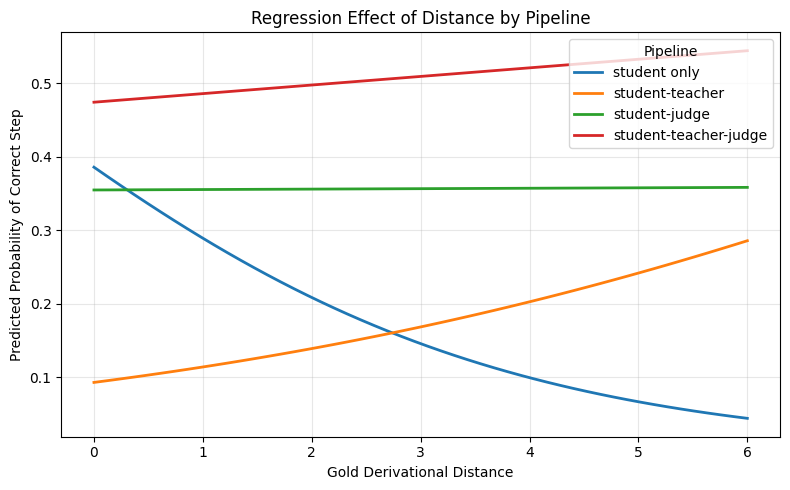

In [169]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pipelines = df_all['pipeline'].unique()

distance_range = np.linspace(
    df_all['KG_distance'].min(),
    df_all['KG_distance'].max(),
    50
)

mean_complexity = df_all['KG_complexity'].mean()

plot_rows = []
for p in pipelines:
    for d in distance_range:
        plot_rows.append({
            'pipeline': p,
            'KG_distance': d,
            'KG_complexity': mean_complexity
        })

plot_df = pd.DataFrame(plot_rows)

# Predict probabilities from fitted model
plot_df['pred_prob'] = model.predict(plot_df)

plt.figure(figsize=(8, 5))
for p in pipelines:
    subset = plot_df[plot_df['pipeline'] == p]
    plt.plot(
        subset['KG_distance'],
        subset['pred_prob'],
        label=p,
        linewidth=2
    )

plt.xlabel("Gold Derivational Distance")
plt.ylabel("Predicted Probability of Correct Step")
plt.title("Regression Effect of Distance by Pipeline")
plt.legend(title="Pipeline")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


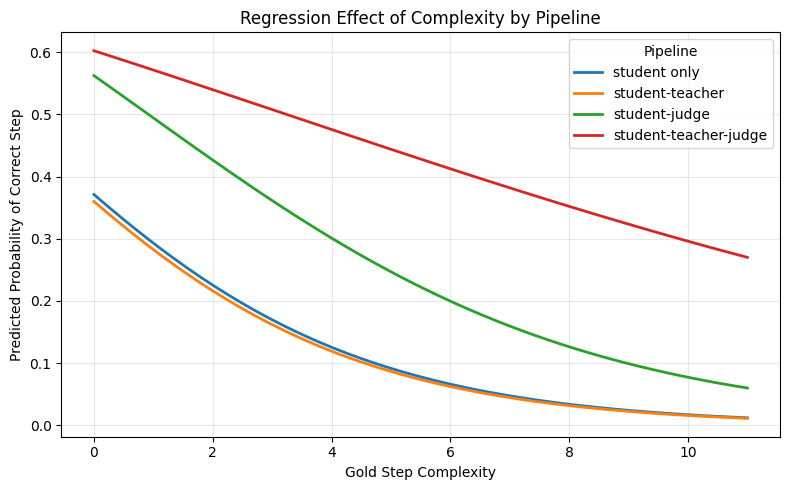

In [170]:
complexity_range = np.linspace(
    df_all['KG_complexity'].min(),
    df_all['KG_complexity'].max(),
    50
)

mean_distance = df_all['KG_distance'].mean()

plot_rows = []
for p in pipelines:
    for c in complexity_range:
        plot_rows.append({
            'pipeline': p,
            'KG_complexity': c,
            'KG_distance': mean_distance
        })

plot_df = pd.DataFrame(plot_rows)
plot_df['pred_prob'] = model.predict(plot_df)

plt.figure(figsize=(8, 5))
for p in pipelines:
    subset = plot_df[plot_df['pipeline'] == p]
    plt.plot(
        subset['KG_complexity'],
        subset['pred_prob'],
        label=p,
        linewidth=2
    )

plt.xlabel("Gold Step Complexity")
plt.ylabel("Predicted Probability of Correct Step")
plt.title("Regression Effect of Complexity by Pipeline")
plt.legend(title="Pipeline")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


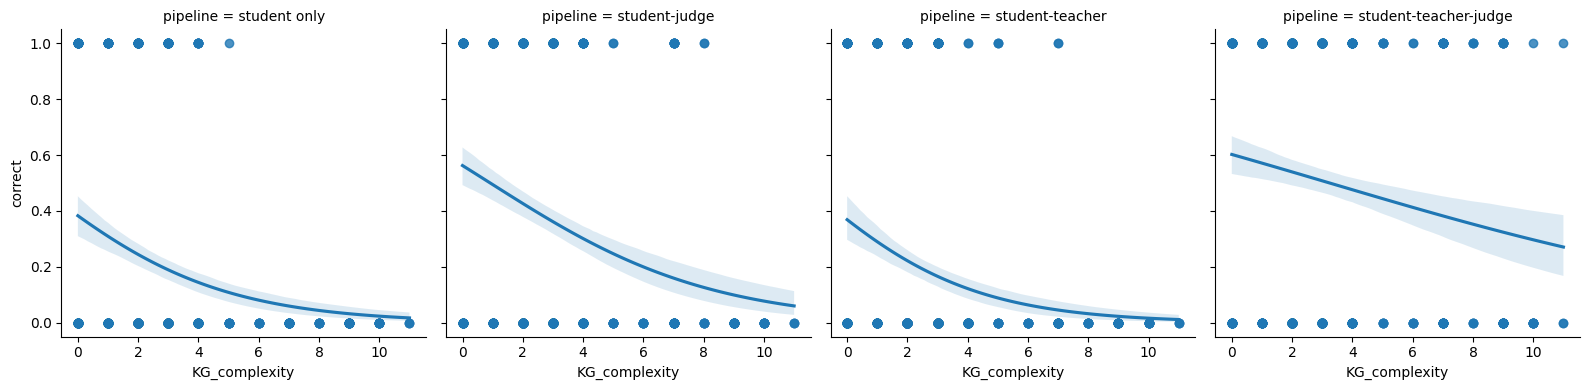

In [171]:
import seaborn as sns

sns.lmplot(
    data=df_all,
    x="KG_complexity",
    y="correct",
    col="pipeline",
    logistic=True,
    ci=95,
    height=4,
    aspect=1
)


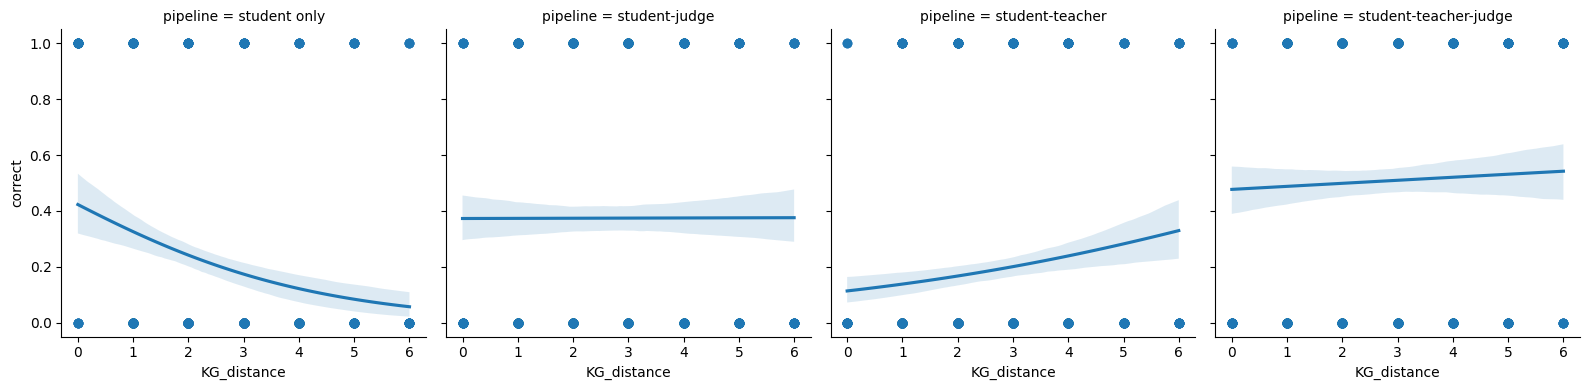

In [172]:
import seaborn as sns

sns.lmplot(
    data=df_all,
    x="KG_distance",
    y="correct",
    col="pipeline",
    logistic=True,
    ci=95,
    height=4,
    aspect=1
)


# Regression for student details 

In [173]:
# add student_complexity, student_depth, student_distance from df to df_student, df_teacher, df_judge, df_teacher_judge
df_student_1= pd.concat([df_student, df[['student_complexity', 'student_depth', 'student_distance']]], axis=1)
df_teacher_1 = pd.concat([df_teacher, df[['student_complexity', 'student_depth', 'student_distance']]], axis=1)
df_judge_1 = pd.concat([df_judge, df[['student_complexity', 'student_depth', 'student_distance']]], axis=1)
df_teacher_judge_1 = pd.concat([df_teacher_judge, df[['student_complexity', 'student_depth', 'student_distance']]], axis=1)

# Safe function to evaluate literal expressions - handles both strings and already-parsed lists
def safe_literal_eval(x):
    if isinstance(x, str):
        return ast.literal_eval(x)
    elif isinstance(x, (list, tuple)):
        return x
    else:
        return x

df['known_expressions'] = df['known_expressions'].apply(safe_literal_eval)
df['known_expressions_length'] = df['known_expressions'].apply(len)
df['student_parent_statements'] = df['student_parent_statements'].apply(safe_literal_eval)
df['parents_length'] = df['student_parent_statements'].apply(len)
df['student_parent_complexity'] = df['student_parent_complexities'].apply(lambda x: sum(ast.literal_eval(x) if isinstance(x, str) else x))
df['student_parent_complexity'] = df['student_parent_complexities'].apply(sum)


# Now add this to all dataframes
df_student_1['known_expressions'] = df['known_expressions_length']
df_teacher_1['known_expressions'] = df['known_expressions_length']
df_judge_1['known_expressions'] = df['known_expressions_length']
df_teacher_judge_1['known_expressions'] = df['known_expressions_length']

df_student_1['parents_length'] = df['parents_length']
df_teacher_1['parents_length'] = df['parents_length']
df_judge_1['parents_length'] = df['parents_length']
df_teacher_judge_1['parents_length'] = df['parents_length']

df_student_1['parent_complexity'] = df['student_parent_complexity']
df_teacher_1['parent_complexity'] = df['student_parent_complexity']
df_judge_1['parent_complexity'] = df['student_parent_complexity']
df_teacher_judge_1['parent_complexity'] = df['student_parent_complexity']


df_student.head()
df_all_1 = pd.concat([df_student_1, df_teacher_1, df_judge_1, df_teacher_judge_1])
print(df_all_1.shape)
df_all_1.head()

# Regression for student details 
# add student_complexity, student_depth, student_distance from to df_student

(2064, 12)


,id,KG_complexity,KG_distance,correct,model,pipeline,student_complexity,student_depth,student_distance,known_expressions,parents_length,parent_complexity
0,450,7,3,0,GPT-4.1,student only,3,3.0,4,7,1,3
1,451,2,4,0,GPT-4.1,student only,3,3.0,5,10,1,4
2,452,0,5,1,GPT-4.1,student only,0,1.0,5,3,2,2
3,453,7,3,0,GPT-4.1,student only,0,4.0,3,7,2,8
4,454,6,4,0,GPT-4.1,student only,0,4.0,3,6,2,11


In [174]:
df_all_1['pipeline'].unique()

array(['student only', 'student-teacher', 'student-judge',
       'student-teacher-judge'], dtype=object)

In [175]:
formula_interaction = """
correct ~ pipeline + KG_complexity + KG_distance + 
          pipeline:KG_complexity + pipeline:KG_distance

"""
result = smf.logit(
    formula=formula_interaction,
    data=df_all_1
).fit()

print(result.summary())


Optimization terminated successfully.
         Current function value: 0.549311
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                correct   No. Observations:                 2064
Model:                          Logit   Df Residuals:                     2052
Method:                           MLE   Df Model:                           11
Date:                Mon, 12 Jan 2026   Pseudo R-squ.:                  0.1255
Time:                        15:51:14   Log-Likelihood:                -1133.8
converged:                       True   LL-Null:                       -1296.5
Covariance Type:            nonrobust   LLR p-value:                 3.770e-63
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
Intercept                         

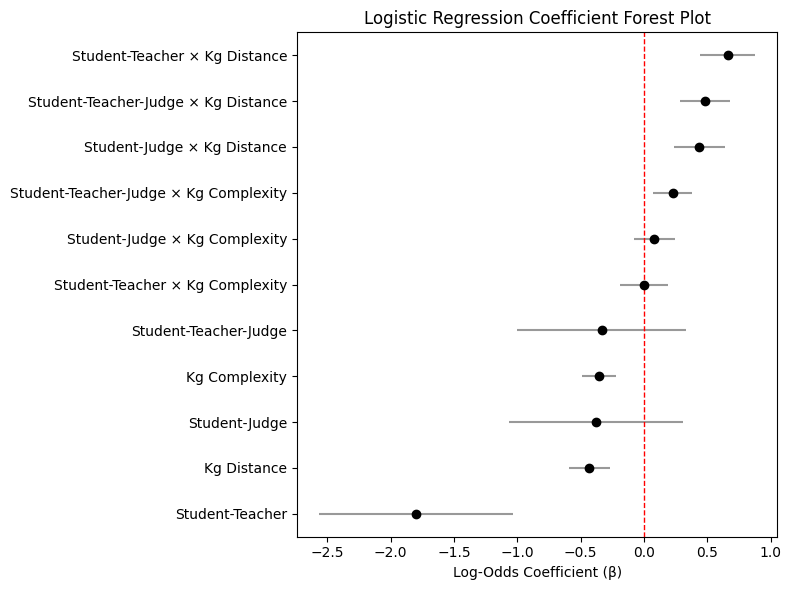

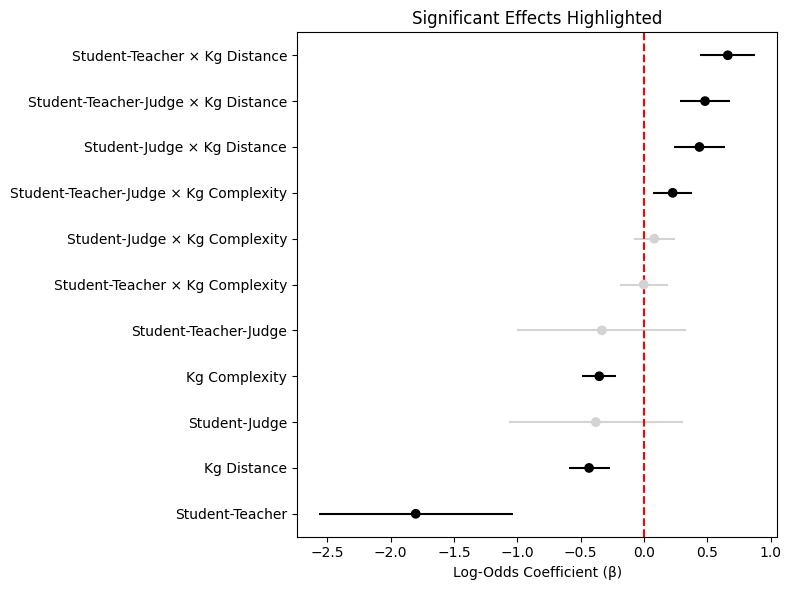

In [176]:
# Extract coefficients from statsmodels
import pandas as pd
import numpy as np

# Extract coefficients
coef_df = pd.DataFrame({
    "term": result.params.index,
    "coef": result.params.values,
    "ci_low": result.conf_int()[0].values,
    "ci_high": result.conf_int()[1].values,
    "p_value": result.pvalues.values
})

# Remove intercept (usually not informative in forest plots)
coef_df = coef_df[coef_df["term"] != "Intercept"]

# Optional: sort for nicer plotting
coef_df = coef_df.sort_values("coef")

# Clean up term names (important for paper quality)
def pretty_term(term):
    term = term.replace("pipeline[T.", "")
    term = term.replace("]", "")
    term = term.replace(":", " × ")
    term = term.replace("_", " ")
    return term.title()

coef_df["term_pretty"] = coef_df["term"].apply(pretty_term)

# Draw the coefficient forest plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plot confidence intervals
plt.hlines(
    y=coef_df["term_pretty"],
    xmin=coef_df["ci_low"],
    xmax=coef_df["ci_high"],
    color="gray",
    alpha=0.8
)

# Plot point estimates
plt.scatter(
    coef_df["coef"],
    coef_df["term_pretty"],
    color="black",
    zorder=3
)

# Vertical zero line
plt.axvline(0, color="red", linestyle="--", linewidth=1)

plt.xlabel("Log-Odds Coefficient (β)")
plt.ylabel("")
plt.title("Logistic Regression Coefficient Forest Plot")

plt.tight_layout()
plt.show()


# Highlight statistically significant effects (optional but recommended)
sig = coef_df["p_value"] < 0.05

plt.figure(figsize=(8, 6))

plt.hlines(
    coef_df["term_pretty"],
    coef_df["ci_low"],
    coef_df["ci_high"],
    color=["black" if s else "lightgray" for s in sig]
)

plt.scatter(
    coef_df["coef"],
    coef_df["term_pretty"],
    c=["black" if s else "lightgray" for s in sig],
    zorder=3
)

plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Log-Odds Coefficient (β)")
plt.title("Significant Effects Highlighted")
plt.tight_layout()
plt.show()




In [177]:
model_clustered = smf.logit(
    formula=formula_interaction,
    data=df_all_1
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_all_1["id"]}
)

print(model_clustered.summary())


Optimization terminated successfully.
         Current function value: 0.549311
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                correct   No. Observations:                 2064
Model:                          Logit   Df Residuals:                     2052
Method:                           MLE   Df Model:                           11
Date:                Mon, 12 Jan 2026   Pseudo R-squ.:                  0.1255
Time:                        15:51:14   Log-Likelihood:                -1133.8
converged:                       True   LL-Null:                       -1296.5
Covariance Type:              cluster   LLR p-value:                 3.770e-63
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
Intercept                         